In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import torch
from torch import nn
from torch.nn import functional as F
import copy

import sys
import os
import pathlib
import pickle
import itertools
from typing import Callable

from omegaconf import OmegaConf

import tqdm.notebook as tqdm

In [2]:
sys.path.append(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src')

import data_preparation
import models_gnn
import model_loader
import losses
import run_experiment

In [3]:
device = torch.device('cpu')

if torch.cuda.is_available():
    device = torch.device('cuda')

device

device(type='cuda')

In [4]:
path = pathlib.Path(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps\sym_no_reg\neighbors_init\dump_neighbors_init_seed_269_adj_269.bin')
print(f"{path=}")

with open(path, 'rb') as f:
    target_run_info = pickle.load(f)

path=WindowsPath('C:/Users/Vladimir/PycharmProjects/EEGPatternRecognition/dumps/sym_no_reg/neighbors_init/dump_neighbors_init_seed_269_adj_269.bin')


In [5]:
path = pathlib.Path(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\dumps\sym_no_reg\random_init\dump_random_init_seed_269_adj_4615.bin')
print(f"{path=}")

with open(path, 'rb') as f:
    random_run_info = pickle.load(f)

path=WindowsPath('C:/Users/Vladimir/PycharmProjects/EEGPatternRecognition/dumps/sym_no_reg/random_init/dump_random_init_seed_269_adj_4615.bin')


<Axes: >

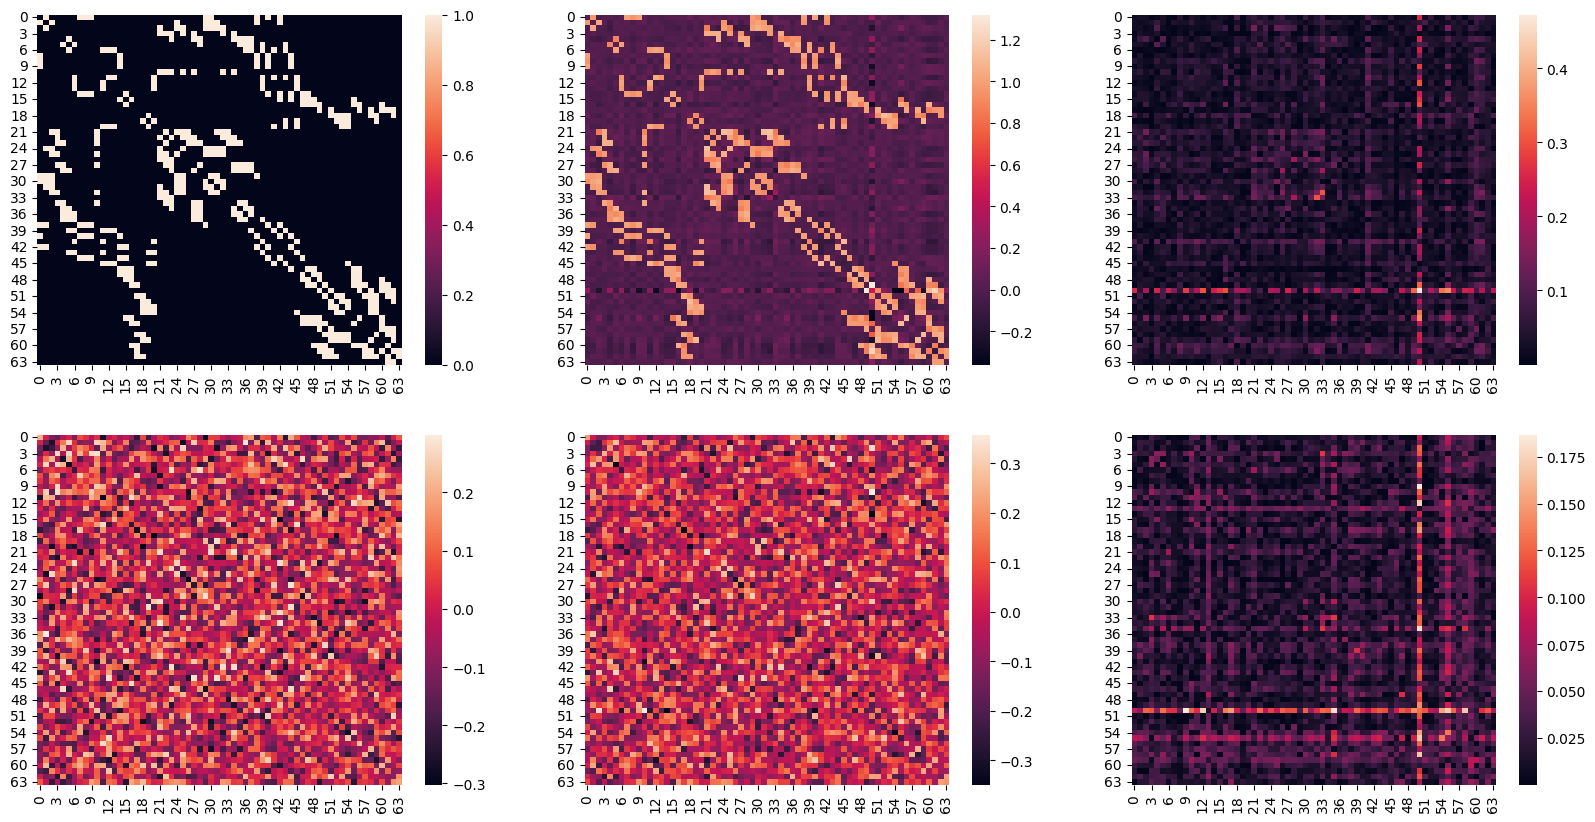

In [6]:
_, ax = plt.subplots(ncols=3, nrows=2, figsize=(20, 10))

adj_init = target_run_info['adj']['init']
adj_final = target_run_info['adj']['final']
adj_init = (adj_init + adj_init.T) / 2
adj_final = (adj_final + adj_final.T) / 2
sns.heatmap(adj_init, ax=ax[0, 0])
sns.heatmap(adj_final, ax=ax[0, 1])
sns.heatmap(np.abs(adj_init - adj_final), ax=ax[0, 2])


adj_init = random_run_info['adj']['init']
adj_final = random_run_info['adj']['final']
adj_init = (adj_init + adj_init.T) / 2
adj_final = (adj_final + adj_final.T) / 2
sns.heatmap(adj_init, ax=ax[1, 0])
sns.heatmap(adj_final, ax=ax[1, 1])
sns.heatmap(np.abs(adj_init - adj_final), ax=ax[1, 2])

In [7]:
def adj_conv(adj_1: torch.Tensor, adj_2: torch.Tensor) -> Callable:
    def conv(theta: float) -> torch.Tensor:
        return adj_2 * theta + adj_1 * (1.0 -  theta)
    
    return conv

In [8]:
def get_nn(base_nn, adj_matrix, cfg):
    if isinstance(adj_matrix, np.ndarray):
        adj_matrix = torch.from_numpy(adj_matrix)

    adj_layer = models_gnn.AdjLayer(
        n_channels=cfg.n_channels, 
        init_mat=adj_matrix,
        is_sym=cfg.adj_sym
    )

    base_nn.gc.adj = adj_layer

    return base_nn

In [9]:
@torch.inference_mode
def score_model(model: nn.Module, dataloader: torch.utils.data.DataLoader, criterion: losses.HybridLoss):
    model.eval()
    running_TP, running_TN, running_FP, running_FN = 0, 0, 0, 0
    running_loss = 0.0
    num_objs = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        inputs_size = inputs.size(0)

        outputs = model(inputs)
        loss = criterion(input=outputs, target=labels, adj=model.gc.adj.adj_mat)

        _, preds = torch.max(outputs, 1)
        _, true_y = torch.max(labels.data, 1)

        P = torch.sum(preds)
        N = torch.sum(1 - preds)
        TP = torch.sum(torch.masked_select(true_y, preds == 1))
        TN = torch.sum(torch.masked_select(1 - true_y, preds == 0))
        FP = P - TP
        FN = N - TN

        running_loss += loss.item() * inputs_size
        running_TP += TP.item()
        running_TN += TN.item()
        running_FP += FP.item()
        running_FN += FN.item()
        num_objs += inputs_size

    running_loss = running_loss / num_objs

    return {
        'loss': running_loss,
        'TP': running_TP,
        'TN': running_TN,
        'FP': running_FP,
        'FN': running_FN,
    }

In [10]:
def calc_accuracy(TP: int, TN: int, FP: int, FN: int, **kwargs):
    return (TP + TN) / (TP + TN + FP + FN)

def calc_recall(TP: int, TN: int, FP: int, FN: int, **kwargs):
    return TP / (TP + FN)

def calc_precision(TP: int, TN: int, FP: int, FN: int, **kwargs):
    return TP / (TP + FP)

def calc_f1(TP: int, TN: int, FP: int, FN: int, **kwargs):
    precision = calc_precision(TP=TP, TN=TN, FP=FP, FN=FN)
    recall = calc_recall(TP=TP, TN=TN, FP=FP, FN=FN)

    f1 = 2 * precision * recall / (precision + recall)

    return f1

# Замороженные веса

In [ ]:
cfg_path = r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\configs\viewer_cfg.yaml'
cfg = OmegaConf.load(cfg_path) 

train_res = run_experiment.run(cfg_path)

In [ ]:
base_nn = copy.deepcopy(train_res['model'])

base_nn

In [ ]:
# base_nn = get_nn(base_nn, adj_matrix=random_run_info['adj']['init'])
# base_nn = get_nn(base_nn, adj_matrix=target_run_info['adj']['init'])

# base_nn.gc.adj.adj_mat

In [ ]:
train_dataset, test_dataset = data_preparation.load_dataset(cfg)
_, test_dataloader = data_preparation.get_dataloaders(cfg, train_dataset, test_dataset)

In [ ]:
mid_model = get_nn(base_nn, adj_matrix=random_run_info['adj']['final']).to(device)
criterion = model_loader.load_criterion(cfg)
scores = score_model(mid_model, test_dataloader, criterion)

f1 = calc_f1(**scores)
accuracy = calc_accuracy(**scores)

print(scores)
print(f"{f1=}\t{accuracy=}")

In [ ]:
mid_model = get_nn(base_nn, adj_matrix=target_run_info['adj']['final']).to(device)
scores = score_model(mid_model, test_dataloader, criterion)

f1 = calc_f1(**scores)
accuracy = calc_accuracy(**scores)

print(scores)
print(f"{f1=}\t{accuracy=}")

In [ ]:
adj_geodetic = adj_conv(
    # adj_1=random_run_info['adj']['final'],
    adj_1=train_res['logs']['adj']['final'],
    adj_2=target_run_info['adj']['final']
)
criterion = model_loader.load_criterion(cfg)

thetas = np.linspace(0.0, 1.0, num=500)

f1_ls = np.zeros_like(thetas)
acc_ls = np.zeros_like(thetas)
loss_ls = np.zeros_like(thetas)

for i, theta in enumerate(thetas):
    adj_mat = adj_geodetic(theta)
    mid_model = get_nn(base_nn, adj_matrix=adj_mat).to(device)

    scores = score_model(mid_model, test_dataloader, criterion)
    f1 = calc_f1(**scores)
    accuracy = calc_accuracy(**scores)

    f1_ls[i] = f1
    acc_ls[i] = accuracy
    loss_ls[i] = scores['loss']

In [ ]:
_, ax = plt.subplots(ncols=3, figsize=(20, 6))

ax[0].plot(thetas, f1_ls)
ax[0].set_xlabel('Theta')
ax[0].set_ylabel('F1-score')

ax[1].plot(thetas, acc_ls)
ax[1].set_xlabel('Theta')
ax[1].set_ylabel('Accuracy')

ax[2].plot(thetas, loss_ls)
ax[2].set_xlabel('Theta')
ax[2].set_ylabel('Loss')

In [ ]:
_, ax = plt.subplots(ncols=3, figsize=(20, 6))

ax[0].plot(thetas, f1_ls)
ax[0].set_xlabel('Theta')
ax[0].set_ylabel('F1-score')

ax[1].plot(thetas, acc_ls)
ax[1].set_xlabel('Theta')
ax[1].set_ylabel('Accuracy')

ax[2].plot(thetas, loss_ls)
ax[2].set_xlabel('Theta')
ax[2].set_ylabel('Loss')

# Обучение с различными инициализациями

In [11]:
def run_sample(theta: float, adj_geodetic):
    cfg_path = r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\configs\viewer_ft_cfg.yaml'
    work_cfg_path = r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\configs\viewer_ft_working.yaml'
    init_dump_path = r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\viewer_adj_init.bin'

    # uploading config
    cfg = OmegaConf.load(cfg_path)
    cfg['run_name'] = f'viewer_{theta=:.4f}'.replace('.', '')
    cfg['adj_init'] = init_dump_path

    with open(work_cfg_path, 'w') as f:
        print(
            OmegaConf.to_yaml(cfg, resolve=True),
            file=f
        )
    
    # uploading adj_init
    adj = adj_geodetic(theta)
    if isinstance(adj, np.ndarray):
        adj = torch.from_numpy(adj)
    with open(init_dump_path, 'wb') as f:
        pickle.dump(
            obj=adj,
            file=f
        )

    train_res = run_experiment.run(work_cfg_path)

    return train_res

In [12]:
cfg_path = r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\configs\viewer_frozen_cfg.yaml'
cfg = OmegaConf.load(cfg_path) 

In [13]:
train_res_ls = []

thetas = np.linspace(0.0, 1.0, num=10)
adj_geodetic = adj_conv(
    adj_1=random_run_info['adj']['init'],
    adj_2=target_run_info['adj']['init']
)

for i, theta in tqdm.tqdm(enumerate(thetas), total=len(thetas)):
    train_res = run_sample(theta, adj_geodetic)
    train_res_ls.append(train_res)

  0%|          | 0/10 [00:00<?, ?it/s]

tensor([42,  0,  0,  ...,  0,  0,  0], dtype=torch.uint8)


C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformati

train_stats=defaultdict(<function train_model.<locals>.<lambda> at 0x0000019A6CE68360>, {'TP': [7217, 7962, 8117, 8076, 7953, 7922, 8091, 7993, 7977, 8109], 'TN': [5770, 5634, 5895, 6269, 6628, 6880, 6914, 7235, 7357, 7333], 'FP': [6980, 7116, 6855, 6481, 6122, 5870, 5836, 5515, 5393, 5417], 'FN': [5533, 4788, 4633, 4674, 4797, 4828, 4659, 4757, 4773, 4641], 'accuracy': [0.5092941176470588, 0.5331764705882353, 0.5494901960784314, 0.5625490196078431, 0.5718039215686275, 0.5804705882352941, 0.5884313725490196, 0.5971764705882353, 0.6013333333333334, 0.6055686274509804], 'f1': [0.5356440420083868, 0.5722294092281156, 0.585599884568213, 0.5914966858314717, 0.5929543336439889, 0.5969406977620375, 0.6065899463957718, 0.6088049356386626, 0.6107963246554365, 0.6172172324554727]})

val_stats=defaultdict(<function train_model.<locals>.<lambda> at 0x0000019A023B0360>, {'TP': [1281, 1924, 1932, 1850, 1780, 1756, 1801, 1790, 1782, 1822, 1788], 'TN': [9121, 6192, 6335, 6832, 7401, 7641, 7676, 7946, 

C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformati

...

train_stats=defaultdict(<function train_model.<locals>.<lambda> at 0x0000019A6CCFBA60>, {'TP': [7320, 7809, 8354, 8338, 8177, 8078, 8084, 8014, 8123, 8248], 'TN': [5425, 5356, 5029, 5425, 5998, 6343, 6392, 6517, 6543, 6475], 'FP': [7325, 7394, 7721, 7325, 6752, 6407, 6358, 6233, 6207, 6275], 'FN': [5430, 4941, 4396, 4412, 4573, 4672, 4666, 4736, 4627, 4502], 'accuracy': [0.49980392156862746, 0.5162745098039215, 0.5248235294117647, 0.5397254901960784, 0.5558823529411765, 0.5655294117647058, 0.5676862745098039, 0.569843137254902, 0.5751372549019608, 0.5773725490196079], 'f1': [0.5344040883372878, 0.5587235717096556, 0.5796357328707719, 0.5869144405729773, 0.5908450449799486, 0.5932072700569121, 0.5945866431303325, 0.5936955958069415, 0.5999261447562778, 0.6048472848604847]})

val_stats=defaultdict(<function train_model.<locals>.<lambda> at 0x0000019A029E8400>, {'TP': [1163, 1784, 1945, 2026, 2014, 1857, 1900, 1851, 1819, 1866, 1897], 'TN': [9124, 6320, 5836, 5763, 6131, 7093, 6980, 7351,

C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformati

train_stats=defaultdict(<function train_model.<locals>.<lambda> at 0x0000019A02A19EE0>, {'TP': [7326, 7808, 8328, 8296, 8165, 8064, 8095, 8035, 8063, 8243], 'TN': [5455, 5382, 5066, 5470, 6008, 6324, 6367, 6525, 6542, 6474], 'FP': [7295, 7368, 7684, 7280, 6742, 6426, 6383, 6225, 6208, 6276], 'FN': [5424, 4942, 4422, 4454, 4585, 4686, 4655, 4715, 4687, 4507], 'accuracy': [0.5012156862745099, 0.5172549019607843, 0.5252549019607843, 0.539843137254902, 0.5558039215686275, 0.5642352941176471, 0.5671372549019608, 0.5709803921568627, 0.5727450980392157, 0.5771372549019608], 'f1': [0.5353110956852142, 0.5591921506839503, 0.5790974202072179, 0.5857516062981006, 0.5904472647069458, 0.5920704845814978, 0.5946084912589982, 0.5949648278415403, 0.5967950853040227, 0.6045692911364553]})

val_stats=defaultdict(<function train_model.<locals>.<lambda> at 0x0000019A6CE68360>, {'TP': [1163, 1786, 1927, 2026, 2009, 1864, 1892, 1847, 1817, 1852, 1878], 'TN': [9121, 6370, 5900, 5808, 6177, 7115, 6977, 7356, 

C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  train_array.set_montage(self.eloc)
C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\src\utils.py:83: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformati

train_stats=defaultdict(<function train_model.<locals>.<lambda> at 0x0000019A6CCFBA60>, {'TP': [7321, 7790, 8318, 8292, 8160, 8039, 8088, 8028, 8053, 8237], 'TN': [5475, 5400, 5066, 5468, 6011, 6319, 6367, 6521, 6573, 6483], 'FP': [7275, 7350, 7684, 7282, 6739, 6431, 6383, 6229, 6177, 6267], 'FN': [5429, 4960, 4432, 4458, 4590, 4711, 4662, 4722, 4697, 4513], 'accuracy': [0.5018039215686274, 0.5172549019607843, 0.5248627450980392, 0.5396078431372549, 0.5557254901960784, 0.5630588235294117, 0.5668627450980392, 0.5705490196078431, 0.5735686274509804, 0.5772549019607843], 'f1': [0.5354347985080085, 0.5586231624238078, 0.5786032276015581, 0.5855105211128372, 0.590256428803935, 0.5906686260102865, 0.5942470886447963, 0.5945125337875367, 0.5969607116382505, 0.6044617303882]})

val_stats=defaultdict(<function train_model.<locals>.<lambda> at 0x0000019A02A19EE0>, {'TP': [1157, 1777, 1924, 2018, 2002, 1865, 1886, 1836, 1817, 1855, 1878], 'TN': [9109, 6401, 5926, 5832, 6135, 7133, 7078, 7356, 749

In [14]:
train_res_ls[0]['logs']['train_curve']['validation'].keys()

dict_keys(['TP', 'TN', 'FP', 'FN', 'accuracy', 'f1', 'loss'])

In [16]:
best_step_idxs = []
best_f1 = []
best_acc = []
best_loss = []

for train_res in train_res_ls:
    f1_scores = train_res['logs']['train_curve']['validation']['f1']
    acc_scores = train_res['logs']['train_curve']['validation']['accuracy']
    loss = train_res['logs']['train_curve']['validation']['loss']
    best_idx = np.argmax(f1_scores)

    best_step_idxs.append(best_idx)
    best_f1.append(f1_scores[best_idx])
    best_acc.append(acc_scores[best_idx])
    best_loss.append(loss[best_idx])

best_step_idxs = np.array(best_step_idxs)
best_f1 = np.array(best_f1)
best_acc = np.array(best_acc)

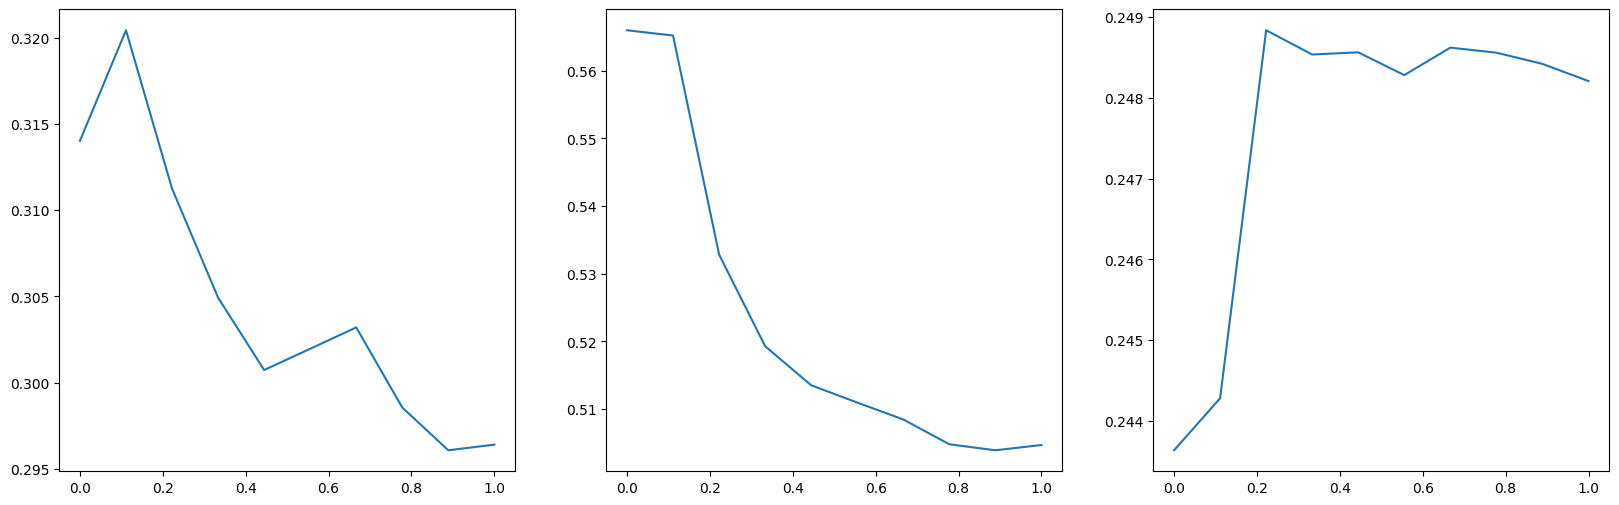

In [18]:
_, ax = plt.subplots(ncols=3, figsize=(20, 6))

ax[0].plot(thetas, best_f1)
ax[1].plot(thetas, best_acc)
ax[2].plot(thetas, best_loss)